In [286]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [287]:
dataset1 = pd.read_csv('/content/Dataset1.csv')
dataset2 = pd.read_csv('/content/Dataset2.csv')
dataset2["Gender"] = dataset2["Gender"].map({"male": 0, "female": 1})
dataset2["Diabetes"] = dataset2["Diabetes"].map({"No diabetes": 0, "Diabetes": 1})

In [288]:
dataset2 = dataset2.drop(columns=["Patient number"])

In [289]:
cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

for col in cols:
    dataset1[col] = dataset1[col].replace(0, np.nan)
    dataset1[col] = dataset1[col].fillna(dataset1[col].mean())

In [290]:
cols = ["Cholesterol", "Glucose", "HDL Chol", "BMI",
        "Systolic BP", "Diastolic BP", "waist", "hip"]

for col in cols:
    dataset2[col] = dataset2[col].replace(0, np.nan)
    dataset2[col] = dataset2[col].fillna(dataset2[col].mean())

In [291]:
X1 = dataset1.iloc[:, :-1]
y1 = dataset1.iloc[:, -1]
X2 = dataset2.iloc[:, :-1]
y2 = dataset2.iloc[:, -1]

In [292]:
X1.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148.0,72.0,35.00000,155.548223,33.6,0.627,50
1,1,85.0,66.0,29.00000,155.548223,26.6,0.351,31
2,8,183.0,64.0,29.15342,155.548223,23.3,0.672,32
3,1,89.0,66.0,23.00000,94.000000,28.1,0.167,21
4,0,137.0,40.0,35.00000,168.000000,43.1,2.288,33


In [293]:
y1.head()

,Outcome
0,1
1,0
2,1
3,0
4,1


In [294]:
X2.head()

,Cholesterol,Glucose,HDL Chol,Chol/HDL ratio,Age,Gender,Height,Weight,BMI,Systolic BP,Diastolic BP,waist,hip,Waist/hip ratio
0,193,77,49,3.9,19,1,61,119,22.5,118,70,32,38,0.84
1,146,79,41,3.6,19,1,60,135,26.4,108,58,33,40,0.83
2,217,75,54,4.0,20,1,67,187,29.3,110,72,40,45,0.89
3,226,97,70,3.2,20,1,64,114,19.6,122,64,31,39,0.79
4,164,91,67,2.4,20,1,70,141,20.2,122,86,32,39,0.82


In [295]:
y2.head()

,Diabetes
0,0
1,0
2,0
3,0
4,0


In [296]:
from sklearn.model_selection import train_test_split
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size = 0.3, random_state = 0)
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size = 0.3, random_state = 0)

In [297]:
def normalize(X):
    return (X - X.mean()) / X.std()

In [298]:
X1_train = normalize(X1_train)
X1_test = normalize(X1_test)

X2_train = normalize(X2_train)
X2_test = normalize(X2_test)

In [299]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [300]:
def train_logistic(X, y, lr=0.01, epochs=1000):
    X = np.array(X)
    y = np.array(y)

    n_samples, n_features = X.shape

    w = np.zeros(n_features)
    b = 0

    for _ in range(epochs):
        linear = np.dot(X, w) + b
        y_pred = sigmoid(linear)

        dw = (1/n_samples) * np.dot(X.T, (y_pred - y))
        db = (1/n_samples) * np.sum(y_pred - y)

        w -= lr * dw
        b -= lr * db

    return w, b

In [301]:
def predict_logistic(X, w, b):
    X = np.array(X)
    linear = np.dot(X, w) + b
    probs = sigmoid(linear)

    return [1 if p >= 0.5 else 0 for p in probs]

In [302]:
def evaluate(y_true, y_pred):
    tp = tn = fp = fn = 0

    for i in range(len(y_true)):
        if y_true[i] == 1 and y_pred[i] == 1:
            tp += 1
        elif y_true[i] == 0 and y_pred[i] == 0:
            tn += 1
        elif y_true[i] == 0 and y_pred[i] == 1:
            fp += 1
        elif y_true[i] == 1 and y_pred[i] == 0:
            fn += 1

    accuracy = (tp + tn) / len(y_true)

    return accuracy, tp, tn, fp, fn

In [303]:
def classification_report_manual(tp, tn, fp, fn):

    # Class 1 (positive)
    precision_1 = tp / (tp + fp) if (tp + fp) != 0 else 0
    recall_1 = tp / (tp + fn) if (tp + fn) != 0 else 0
    f1_1 = 2 * (precision_1 * recall_1) / (precision_1 + recall_1) if (precision_1 + recall_1) != 0 else 0
    support_1 = tp + fn

    # Class 0 (negative)
    precision_0 = tn / (tn + fn) if (tn + fn) != 0 else 0
    recall_0 = tn / (tn + fp) if (tn + fp) != 0 else 0
    f1_0 = 2 * (precision_0 * recall_0) / (precision_0 + recall_0) if (precision_0 + recall_0) != 0 else 0
    support_0 = tn + fp

    total = tp + tn + fp + fn
    accuracy = (tp + tn) / total

    print("Class 0 -> Precision:", round(precision_0, 2),
          "Recall:", round(recall_0, 2),
          "F1:", round(f1_0, 2),
          "Support:", support_0)

    print("Class 1 -> Precision:", round(precision_1, 2),
          "Recall:", round(recall_1, 2),
          "F1:", round(f1_1, 2),
          "Support:", support_1)

    print("Accuracy:", round(accuracy, 2))

In [304]:
w1, b1 = train_logistic(X1_train, y1_train)

y1_pred = predict_logistic(X1_test, w1, b1)

acc1, tp1, tn1, fp1, fn1 = evaluate(list(y1_test), y1_pred)

print("Dataset1 Results:")
print("Accuracy:", acc1)
print("TP:", tp1, "TN:", tn1, "FP:", fp1, "FN:", fn1)

Dataset1 Results:
Accuracy: 0.7402597402597403
TP: 40 TN: 131 FP: 26 FN: 34


In [305]:
classification_report_manual(tp1, tn1, fp1, fn1)

Class 0 -> Precision: 0.79 Recall: 0.83 F1: 0.81 Support: 157
Class 1 -> Precision: 0.61 Recall: 0.54 F1: 0.57 Support: 74
Accuracy: 0.74


In [306]:
import time

start = time.time()

w2, b2 = train_logistic(X2_train, y2_train, lr=0.01, epochs=3000)

end = time.time()

time_before = end - start
print("Execution Time Before:", time_before)

y2_pred = predict_logistic(X2_test, w2, b2)

acc2, tp2, tn2, fp2, fn2 = evaluate(list(y2_test), y2_pred)

print("\nDataset2 Results:")
print("Accuracy:", acc2)
print("TP:", tp2, "TN:", tn2, "FP:", fp2, "FN:", fn2)

Execution Time Before: 0.10587477684020996

Dataset2 Results:
Accuracy: 0.8974358974358975
TP: 12 TN: 93 FP: 2 FN: 10


In [307]:
classification_report_manual(tp2, tn2, fp2, fn2)

Class 0 -> Precision: 0.9 Recall: 0.98 F1: 0.94 Support: 95
Class 1 -> Precision: 0.86 Recall: 0.55 F1: 0.67 Support: 22
Accuracy: 0.9


In [308]:
import math

def correlation(x, y):
    n = len(x)

    mean_x = sum(x) / n
    mean_y = sum(y) / n

    num = 0
    den_x = 0
    den_y = 0

    for i in range(n):
        dx = x[i] - mean_x
        dy = y[i] - mean_y

        num += dx * dy
        den_x += dx ** 2
        den_y += dy ** 2

    return num / math.sqrt(den_x * den_y)

In [309]:
columns1 = dataset1.columns
corr_matrix1 = {}

for col1 in columns1:
    corr_matrix1[col1] = {}
    for col2 in columns1:
        corr_matrix1[col1][col2] = correlation(dataset1[col1], dataset1[col2])

corr_df1 = pd.DataFrame(corr_matrix1)

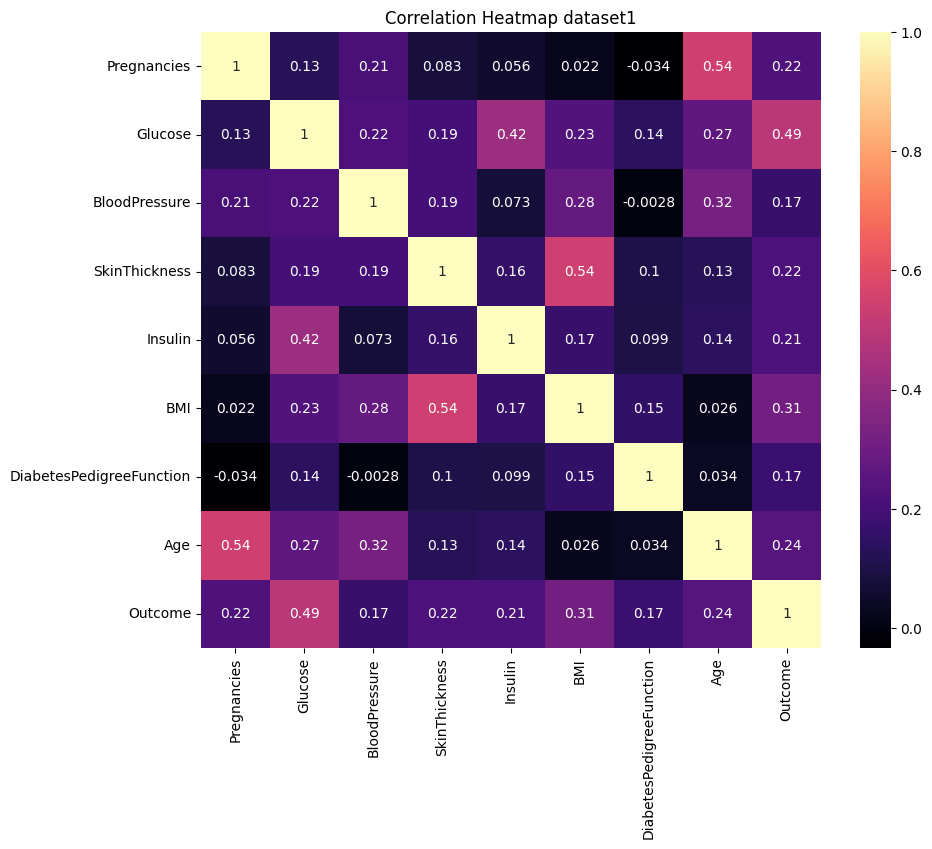

In [310]:
import seaborn as sns
plt.figure(figsize=(10,8))
sns.heatmap(corr_df1, annot=True, cmap="magma")

plt.title("Correlation Heatmap dataset1")
plt.show()

In [311]:
# columns2 = dataset2.columns
# corr_matrix2 = {}

# for col1 in columns2:
#     corr_matrix2[col1] = {}
#     for col2 in columns2:
#         corr_matrix2[col1][col2] = correlation(dataset2[col1], dataset2[col2])

# corr_df2 = pd.DataFrame(corr_matrix2)

In [312]:
# import seaborn as sns
# plt.figure(figsize=(14,12))
# sns.heatmap(corr_df2, annot=True, cmap="magma",annot_kws={"size":8})

# plt.title("Correlation Heatmap dataset2")
# plt.show()

In [313]:
dataset1["NF1"] = ((dataset1["Age"] <= 30) & (dataset1["Glucose"] <= 140)).astype(int)
dataset1["NF2"] = (dataset1["BMI"] <= 30).astype(int)
dataset1["NF3"] = ((dataset1["Age"] <= 30) & (dataset1["Pregnancies"] <= 3)).astype(int)
dataset1["NF4"] = ((dataset1["Glucose"] <= 140) & (dataset1["BloodPressure"] <= 80)).astype(int)
dataset1["NF5"] = ((dataset1["Glucose"] <= 140) & (dataset1["BMI"] <= 45)).astype(int)
print(dataset1[["NF1","NF2","NF3","NF4","NF5"]].head())

   NF1  NF2  NF3  NF4  NF5
0    0    0    0    0    0
1    0    1    0    1    1
2    0    1    0    0    0
3    1    1    1    1    1
4    0    0    0    1    1


In [314]:
columns1 = dataset1.columns
corr_matrix1 = {}

for col1 in columns1:
    corr_matrix1[col1] = {}
    for col2 in columns1:
        corr_matrix1[col1][col2] = correlation(dataset1[col1], dataset1[col2])

corr_df1 = pd.DataFrame(corr_matrix1)

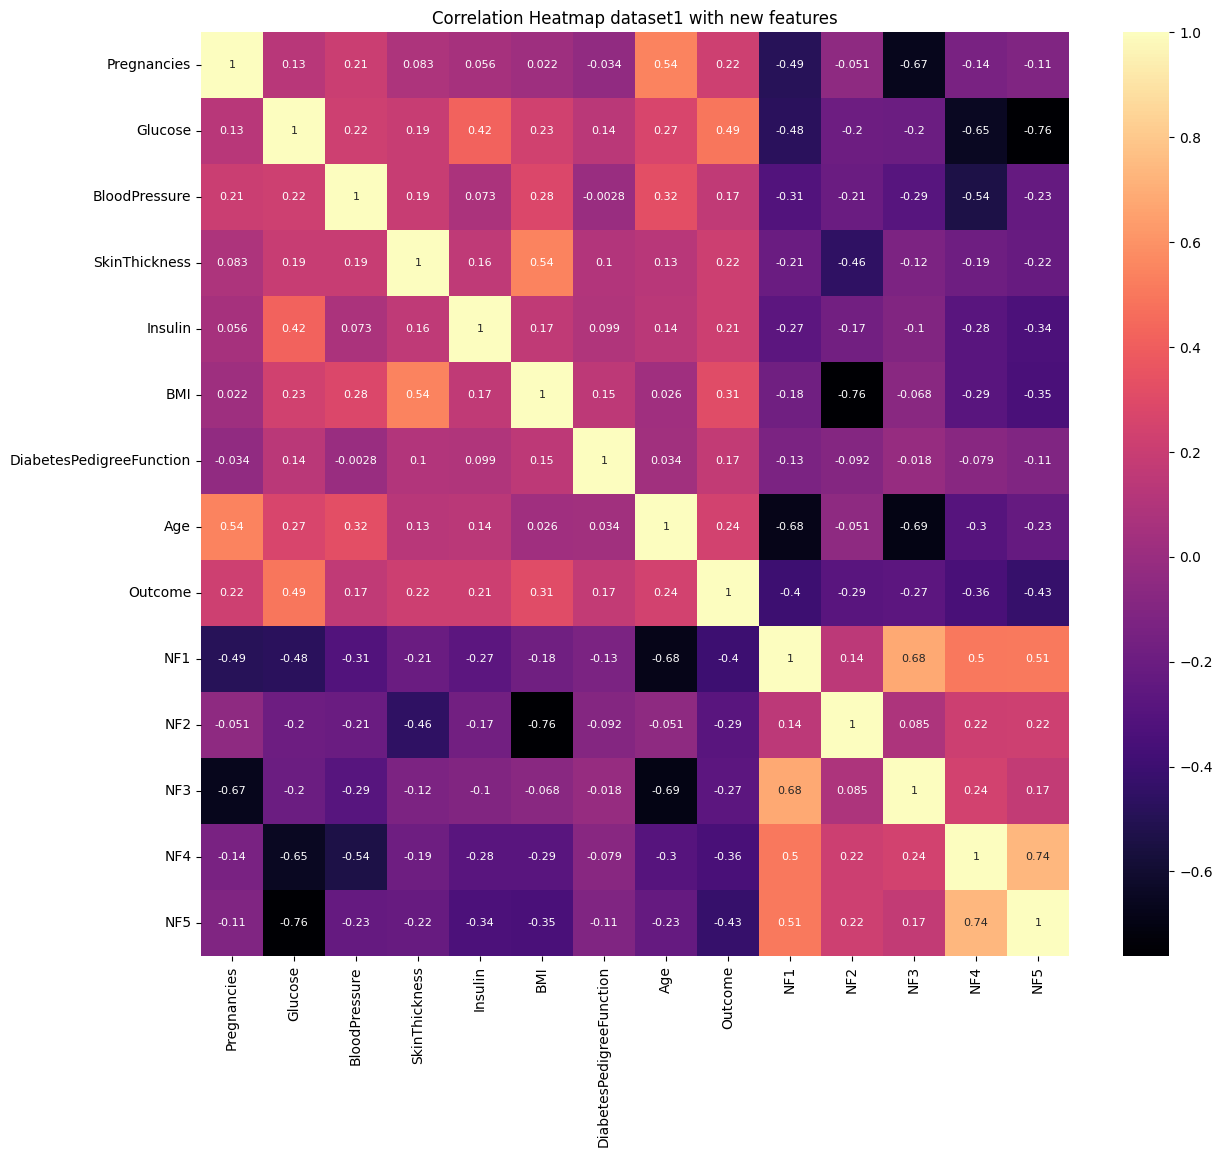

In [315]:
import seaborn as sns
plt.figure(figsize=(14,12))
sns.heatmap(corr_df1, annot=True, cmap="magma",annot_kws={"size":8})

plt.title("Correlation Heatmap dataset1 with new features")
plt.show()

In [316]:
target_corr = corr_df1["Outcome"].abs().sort_values(ascending=False)
print(target_corr)

Outcome                     1.000000
Glucose                     0.492928
NF5                         0.425138
NF1                         0.397519
NF4                         0.355117
BMI                         0.311924
NF2                         0.286415
NF3                         0.267543
Age                         0.238356
Pregnancies                 0.221898
SkinThickness               0.215299
Insulin                     0.214411
DiabetesPedigreeFunction    0.173844
BloodPressure               0.166074
Name: Outcome, dtype: float64


In [317]:
target_corr = target_corr.drop("Outcome")

In [318]:
top_features = target_corr.head(8).index.tolist()
print("Selected Features:", top_features)

Selected Features: ['Glucose', 'NF5', 'NF1', 'NF4', 'BMI', 'NF2', 'NF3', 'Age']


In [319]:
if "Insulin" not in top_features:
    top_features.append("Insulin")

In [320]:
dataset1_new = dataset1[top_features + ["Outcome"]]

In [321]:
columns1 = dataset1_new.columns
corr_matrix1 = {}

for col1 in columns1:
    corr_matrix1[col1] = {}
    for col2 in columns1:
        corr_matrix1[col1][col2] = correlation(dataset1_new[col1], dataset1_new[col2])

corr_df1 = pd.DataFrame(corr_matrix1)

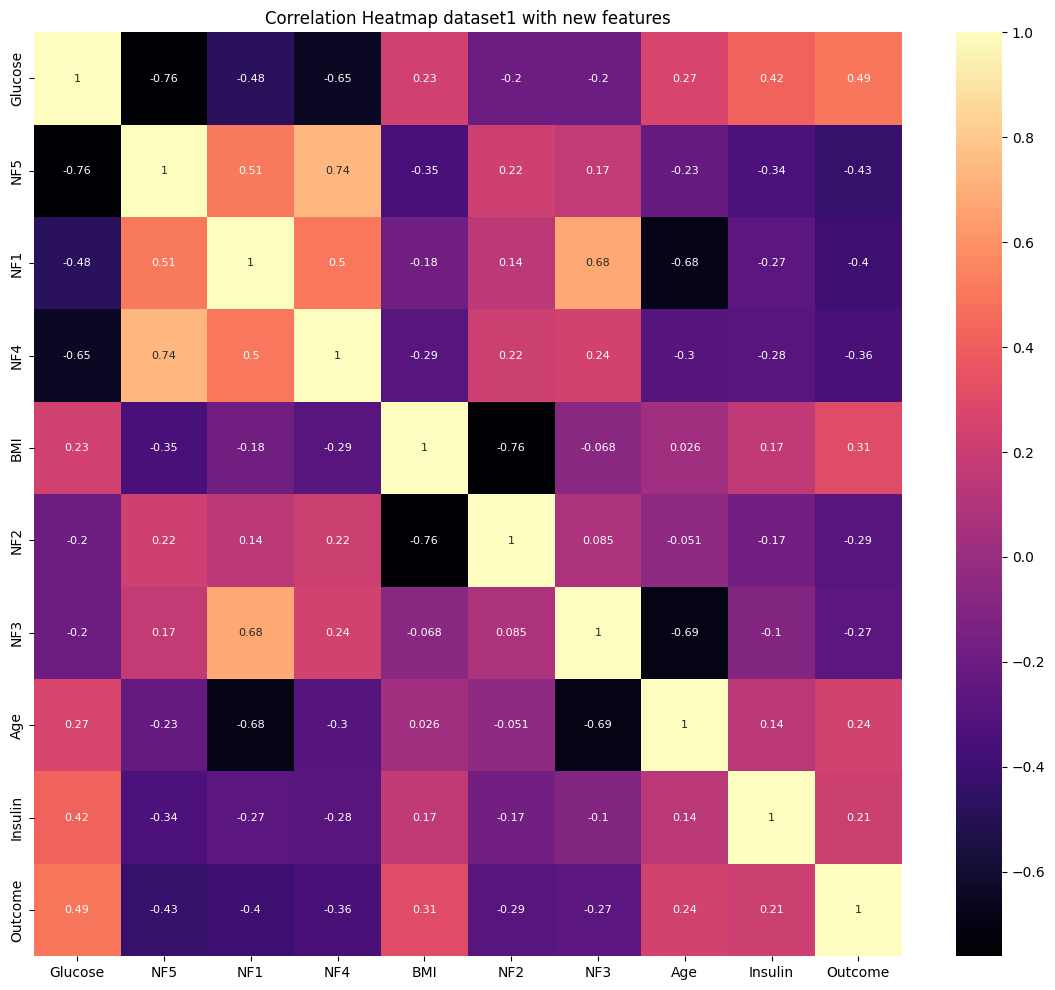

In [322]:
import seaborn as sns
plt.figure(figsize=(14,12))
sns.heatmap(corr_df1, annot=True, cmap="magma",annot_kws={"size":8})

plt.title("Correlation Heatmap dataset1 with new features")
plt.show()

In [323]:
X1_new = dataset1_new.iloc[:, :-1]
y1_new = dataset1_new.iloc[:, -1]

In [324]:
X1_train_new, X1_test_new, y1_train_new, y1_test_new = train_test_split(
    X1_new, y1_new, test_size=0.3, random_state=0
)

In [325]:
print(X1_new.columns)

Index(['Glucose', 'NF5', 'NF1', 'NF4', 'BMI', 'NF2', 'NF3', 'Age', 'Insulin'], dtype='object')


In [326]:
X1_train_new = normalize(X1_train_new)
X1_test_new = normalize(X1_test_new)

In [327]:
w1_new, b1_new = train_logistic(X1_train_new, y1_train_new)

In [328]:
y1_pred_new = predict_logistic(X1_test_new, w1_new, b1_new)

In [329]:
accuracy, tp, tn, fp, fn = evaluate(list(y1_test_new), y1_pred_new)

print("After Feature Selection:")
print("Accuracy:", accuracy)
print(f"TP: {tp} TN: {tn} FP: {fp} FN: {fn}")

After Feature Selection:
Accuracy: 0.7532467532467533
TP: 41 TN: 133 FP: 24 FN: 33


In [330]:
classification_report_manual(tp1_new, tn1_new, fp1_new, fn1_new)

Class 0 -> Precision: 0.8 Recall: 0.85 F1: 0.82 Support: 157
Class 1 -> Precision: 0.63 Recall: 0.55 F1: 0.59 Support: 74
Accuracy: 0.75


In [331]:
X2 = dataset2.iloc[:, :-1]
y2 = dataset2.iloc[:, -1]

In [332]:
from sklearn.feature_selection import SelectKBest, chi2

selector = SelectKBest(score_func=chi2, k=8)
X2_selected = selector.fit_transform(X2, y2)

In [333]:
selected_indices = selector.get_support(indices=True)
selected_features = X2.columns[selected_indices]

print("Selected Features:", list(selected_features))

Selected Features: ['Cholesterol', 'Glucose', 'HDL Chol', 'Chol/HDL ratio', 'Age', 'Weight', 'Systolic BP', 'waist']


In [334]:
dataset2_new = dataset2[selected_features.tolist() + ["Diabetes"]]

In [335]:
X2_new = dataset2_new.iloc[:, :-1]
y2_new = dataset2_new.iloc[:, -1]

In [336]:
X2_train_new, X2_test_new, y2_train_new, y2_test_new = train_test_split(
    X2_new, y2_new, test_size=0.3, random_state=0
)

In [337]:
X2_train_new = normalize(X2_train_new)
X2_test_new = normalize(X2_test_new)

In [338]:
start = time.time()

w2_new, b2_new = train_logistic(X2_train_new, y2_train_new, lr=0.01, epochs=3000)

end = time.time()

time_after = end - start
print("Execution Time After:", time_after)

Execution Time After: 0.12758088111877441


In [339]:
y2_pred_new = predict_logistic(X2_test_new, w2_new, b2_new)

In [340]:
acc2_new, tp2_new, tn2_new, fp2_new, fn2_new = evaluate(list(y2_test_new), y2_pred_new)

print("Dataset2 After Univariate Selection:")
print("Accuracy:", acc2_new)
print("TP:", tp2_new, "TN:", tn2_new, "FP:", fp2_new, "FN:", fn2_new)

Dataset2 After Univariate Selection:
Accuracy: 0.8974358974358975
TP: 12 TN: 93 FP: 2 FN: 10


In [341]:
classification_report_manual(tp2_new, tn2_new, fp2_new, fn2_new)

Class 0 -> Precision: 0.9 Recall: 0.98 F1: 0.94 Support: 95
Class 1 -> Precision: 0.86 Recall: 0.55 F1: 0.67 Support: 22
Accuracy: 0.9


In [342]:
print("Dataset2 Comparison")

print("\nBefore Feature Selection:")
print("Accuracy:", acc2)
print("Execution Time:", time_before)

print("\nAfter Feature Selection (Chi-Square):")
print("Accuracy:", acc2_new)
print("Execution Time:", time_after)

Dataset2 Comparison

Before Feature Selection:
Accuracy: 0.8974358974358975
Execution Time: 0.10587477684020996

After Feature Selection (Chi-Square):
Accuracy: 0.8974358974358975
Execution Time: 0.12758088111877441


In [343]:
def train_svm(X, y, lr=0.001, epochs=1000, lambda_param=0.01):
    X = np.array(X)
    y = np.array(y)

    # Convert labels: 0 → -1, 1 → +1
    y = np.where(y == 0, -1, 1)

    n_samples, n_features = X.shape

    w = np.zeros(n_features)
    b = 0

    for _ in range(epochs):
        for i in range(n_samples):
            condition = y[i] * (np.dot(X[i], w) + b) >= 1

            if condition:
                dw = 2 * lambda_param * w
                db = 0
            else:
                dw = 2 * lambda_param * w - np.dot(X[i], y[i])
                db = -y[i]

            w -= lr * dw
            b -= lr * db

    return w, b

In [344]:
def predict_svm(X, w, b):
    X = np.array(X)
    linear_output = np.dot(X, w) + b
    return [1 if i >= 0 else 0 for i in linear_output]

In [345]:
def max_voting(pred1, pred2):
    final_pred = []

    for p1, p2 in zip(pred1, pred2):
        vote = p1 + p2

        # majority voting
        if vote >= 1:
            final_pred.append(1)
        else:
            final_pred.append(0)

    return final_pred

In [346]:
w1_svm, b1_svm = train_svm(X1_train, y1_train)
y1_pred_svm = predict_svm(X1_test, w1_svm, b1_svm)
acc1_svm, tp1_svm, tn1_svm, fp1_svm, fn1_svm = evaluate(list(y1_test), y1_pred_svm)

print("\nSVM Results (Original Data):")
print("Accuracy:", acc1_svm)
print("TP1:", tp1_svm, "TN1:", tn1_svm, "FP1:", fp1_svm, "FN1:", fn1_svm)


SVM Results (Original Data):
Accuracy: 0.7619047619047619
TP1: 38 TN1: 138 FP1: 19 FN1: 36


In [347]:
w2_svm, b2_svm = train_svm(X2_train, y2_train)

y2_pred_svm = predict_svm(X2_test, w2_svm, b2_svm)

acc2_svm, tp2_svm, tn2_svm, fp2_svm, fn2_svm = evaluate(list(y2_test), y2_pred_svm)

print("\nSVM Results (Original Data):")
print("Accuracy:", acc2_svm)
print("TP2:", tp2_svm, "TN2:", tn2_svm, "FP2:", fp2_svm, "FN2:", fn2_svm)


SVM Results (Original Data):
Accuracy: 0.8974358974358975
TP2: 12 TN2: 93 FP2: 2 FN2: 10


In [348]:
w1_lr, b1_lr = train_logistic(X1_train, y1_train)
y1_pred_lr = predict_logistic(X1_test, w1_lr, b1_lr)

In [349]:
w1_svm, b1_svm = train_svm(X1_train, y1_train)
y1_pred_svm = predict_svm(X1_test, w1_svm, b1_svm)

In [350]:
y1_vote = max_voting(y1_pred_lr, y1_pred_svm)

In [351]:
y1_lr_train = predict_logistic(X1_train, w1_lr, b1_lr)
y1_svm_train = predict_svm(X1_train, w1_svm, b1_svm)

meta_X1_train = np.column_stack((y1_lr_train, y1_svm_train))
meta_y1_train = np.array(y1_train)

w1_meta, b1_meta = train_logistic(meta_X1_train, meta_y1_train)

In [352]:
meta_X1_test = np.column_stack((y1_pred_lr, y1_pred_svm))
y1_stack = predict_logistic(meta_X1_test, w1_meta, b1_meta)

In [353]:
print("\n=== DATASET1 RESULTS ===")

print("\nLogistic:")
print(evaluate(list(y1_test), y1_pred_lr))

print("\nSVM:")
print(evaluate(list(y1_test), y1_pred_svm))

print("\nMax Voting:")
print(evaluate(list(y1_test), y1_vote))

print("\nStacking:")
print(evaluate(list(y1_test), y1_stack))


=== DATASET1 RESULTS ===

Logistic:
(0.7402597402597403, 40, 131, 26, 34)

SVM:
(0.7619047619047619, 38, 138, 19, 36)

Max Voting:
(0.7445887445887446, 41, 131, 26, 33)

Stacking:
(0.7575757575757576, 37, 138, 19, 37)


In [354]:
w2_lr, b2_lr = train_logistic(X2_train, y2_train)
y2_pred_lr = predict_logistic(X2_test, w2_lr, b2_lr)

In [355]:
w2_svm, b2_svm = train_svm(X2_train, y2_train)
y2_pred_svm = predict_svm(X2_test, w2_svm, b2_svm)

In [356]:
y2_vote = max_voting(y2_pred_lr, y2_pred_svm)

In [357]:
y2_lr_train = predict_logistic(X2_train, w2_lr, b2_lr)
y2_svm_train = predict_svm(X2_train, w2_svm, b2_svm)

meta_X2_train = np.column_stack((y2_lr_train, y2_svm_train))
meta_y2_train = np.array(y2_train)

w2_meta, b2_meta = train_logistic(meta_X2_train, meta_y2_train)

In [358]:
meta_X2_test = np.column_stack((y2_pred_lr, y2_pred_svm))
y2_stack = predict_logistic(meta_X2_test, w2_meta, b2_meta)

In [359]:
print("\n=== DATASET2 RESULTS ===")

print("\nLogistic:")
print(evaluate(list(y2_test), y2_pred_lr))

print("\nSVM:")
print(evaluate(list(y2_test), y2_pred_svm))

print("\nMax Voting:")
print(evaluate(list(y2_test), y2_vote))

print("\nStacking:")
print(evaluate(list(y2_test), y2_stack))


=== DATASET2 RESULTS ===

Logistic:
(0.8888888888888888, 11, 93, 2, 11)

SVM:
(0.8974358974358975, 12, 93, 2, 10)

Max Voting:
(0.8974358974358975, 12, 93, 2, 10)

Stacking:
(0.811965811965812, 0, 95, 0, 22)


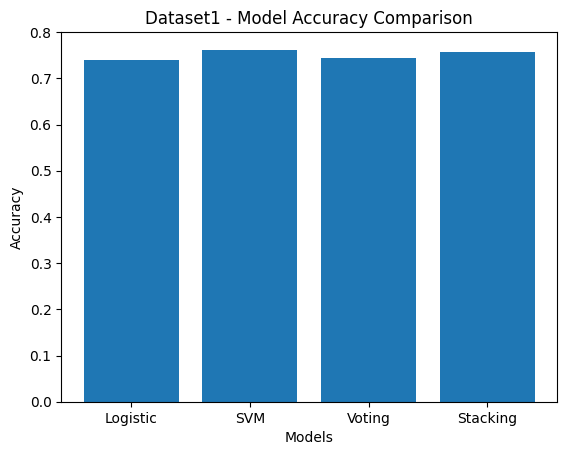

In [360]:
models = ["Logistic", "SVM", "Voting", "Stacking"]
accuracy1 = [acc1, acc1_svm, 0.7445887445887446, 0.7575757575757576]

plt.figure()
plt.bar(models, accuracy1)
plt.title("Dataset1 - Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.show()

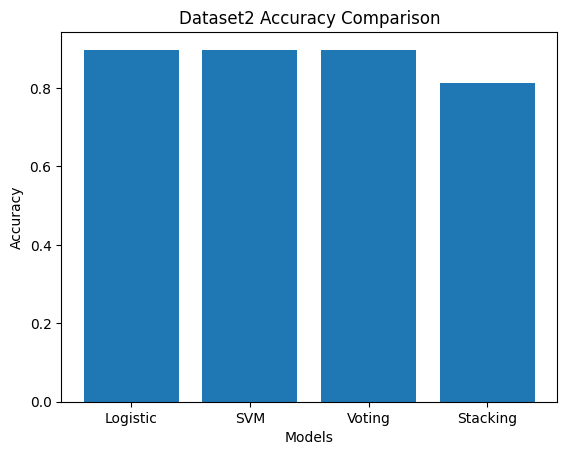

In [361]:
models = ["Logistic", "SVM", "Voting", "Stacking"]
accuracy2 = [acc2, acc2_svm, 0.8974358974358975, 0.811965811965812]

plt.figure()
plt.bar(models, accuracy2)
plt.title("Dataset2 Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.show()